In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [35]:
BASE_PATH = './data/'

#faculty_raw  = pd.read_excel(BASE_PATH + 'faculty-list-2025.xlsx', sheet_name='Sheet1')
# Replace the old faculty file with new file that has the same Employee ID and all the same columns plus Hire Date
faculty_raw = pd.read_excel(BASE_PATH + 'HR Snowflake faculty list 2025 fall update 6.15.2026.xlsx')
copi_raw     = pd.read_excel(BASE_PATH + 'grants-with-coPI.xlsx', sheet_name='Grants with co PI indicator (1)')

print(f'faculty : {faculty_raw.shape}')
print(f'copi    : {copi_raw.shape}')

faculty : (2232, 12)
copi    : (3136, 22)


In [36]:
# Reproduce clean deduplicated dataset with hire date filter applied
# Drop dead columns, parse dates, deduplicate, filter to Northeastern period only

faculty = faculty_raw.drop(columns=['black'], errors='ignore').copy()
faculty['Hire Date'] = pd.to_datetime(faculty['Hire Date'], errors='coerce')

copi = copi_raw.copy()
copi['StartDate'] = pd.to_datetime(copi['StartDate'], errors='coerce')
copi['EndDate']   = pd.to_datetime(copi['EndDate'],   errors='coerce')

# Deduplicate: one row per grant, keep PI (IsCoPI=0) row where possible
copi_deduped = copi.sort_values(['GrantId','IsCoPI']).drop_duplicates(subset='GrantId', keep='first').copy()

# Merge college and hire date from faculty
faculty_slim = faculty[['Employee ID','Superior_Academic_Unit','Academic Track Type',
                          'Academic Rank','Hire Date']].rename(columns={'Employee ID':'ClientFacultyId'})
copi_deduped = copi_deduped.merge(faculty_slim, on='ClientFacultyId', how='left')

# Apply 3-year pre-hire buffer
# Keep grants starting within 3 years before hire date or any time after
# faculty often bring active grants when joining; 3-year buffer captures those
BUFFER_YEARS = 3
total_before_filter = len(copi_deduped)
dollars_before_filter = copi_deduped['TotalDollars'].sum()

copi_deduped = copi_deduped[
    copi_deduped['StartDate'] >= (copi_deduped['Hire Date'] - pd.DateOffset(years=BUFFER_YEARS))
].copy()

# copi_with_college is now the same as copi_deduped
copi_with_college = copi_deduped.copy()

print(f'Unique grants before filter   : {total_before_filter:,}')
print(f'Unique grants after filter    : {len(copi_deduped):,}')
print(f'Grants excluded (pre-hire)    : {total_before_filter - len(copi_deduped):,}')
print()
print(f'Total funding before filter   : ${dollars_before_filter/1e6:,.1f}M')
print(f'Total funding after filter    : ${copi_deduped["TotalDollars"].sum()/1e6:,.1f}M')
print(f'Funding excluded (pre-hire)   : ${(dollars_before_filter - copi_deduped["TotalDollars"].sum())/1e6:,.1f}M')
print()
print(f'Buffer applied                : {BUFFER_YEARS} years before hire date')
print(f'Grants with college           : {copi_with_college["Superior_Academic_Unit"].notna().sum():,}')

Unique grants before filter   : 2,670
Unique grants after filter    : 2,002
Grants excluded (pre-hire)    : 668

Total funding before filter   : $2,149.0M
Total funding after filter    : $1,589.2M
Funding excluded (pre-hire)   : $559.8M

Buffer applied                : 3 years before hire date
Grants with college           : 2,002


In [37]:
print(f'Unmatched (no college) : {copi_with_college["Superior_Academic_Unit"].isnull().sum():,}')

Unmatched (no college) : 0


In [38]:
# Filter faculty to research-active ranks only
# Keep: Professor, Associate Professor, Assistant Professor (all variants including UK and Research)
# Exclude: Teaching professors, Coop coordinators, Lecturers, Clinical, Visiting, Staff

research_ranks = [
    'Professor',
    'Full Professor',
    'Associate Professor',
    'Assistant Professor',
    'Assistant Professor -UK',
    'Associate Professor -UK',
    'Full Professor -UK',
]

faculty_research = faculty[faculty['Academic Rank'].isin(research_ranks)].copy()

print(f'All faculty              : {len(faculty):,}')
print(f'Research-active faculty  : {len(faculty_research):,}')
print(f'Excluded (teaching/other): {len(faculty) - len(faculty_research):,}')
print()

# tenure track breakdown
tenure_all       = faculty[faculty['Academic Track Type'] == 'Tenure Track']
tenure_research  = faculty_research[faculty_research['Academic Track Type'] == 'Tenure Track']
non_tenure_research = faculty_research[faculty_research['Academic Track Type'] != 'Tenure Track']

print(f'Tenure-track in full faculty file      : {len(tenure_all):,}')
print(f'Tenure-track in research_ranks filter  : {len(tenure_research):,}')
print(f'Tenure-track excluded by rank filter   : {len(tenure_all) - len(tenure_research):,}')
print(f'Non-tenure in research_ranks filter    : {len(non_tenure_research):,}')
print()
print('Breakdown by rank:')
print(faculty_research['Academic Rank'].value_counts().to_string())
print()
print('Breakdown by college:')
print(faculty_research['Superior_Academic_Unit'].value_counts().to_string())

All faculty              : 2,232
Research-active faculty  : 1,088
Excluded (teaching/other): 1,144

Tenure-track in full faculty file      : 958
Tenure-track in research_ranks filter  : 958
Tenure-track excluded by rank filter   : 0
Non-tenure in research_ranks filter    : 130

Breakdown by rank:
Academic Rank
Professor                  433
Associate Professor        268
Assistant Professor        257
Assistant Professor -UK     75
Associate Professor -UK     48
Full Professor -UK           7

Breakdown by college:
Superior_Academic_Unit
College of Engineering                       207
College of Science                           182
College of Social Sciences and Humanities    156
Northeastern University London               116
College of Arts, Media and Design            103
D'Amore-McKim School of Business              93
Bouvé College of Health Sciences              87
Khoury College of Computer Sciences           80
School of Law                                 33
Mills College a

In [39]:
# remove rows with no meaningful college assignment
exclude_colleges = ['Northeastern University']
faculty_research = faculty_research[~faculty_research['Superior_Academic_Unit'].isin(exclude_colleges)].copy()

print(f'All faculty              : {len(faculty):,}')
print(f'Research-active faculty  : {len(faculty_research):,}')
print(f'Excluded (teaching/other): {len(faculty) - len(faculty_research):,}')
print()

tenure_all          = faculty[faculty['Academic Track Type'] == 'Tenure Track']
tenure_research     = faculty_research[faculty_research['Academic Track Type'] == 'Tenure Track']
non_tenure_research = faculty_research[faculty_research['Academic Track Type'] != 'Tenure Track']

print(f'Tenure-track in full faculty file      : {len(tenure_all):,}')
print(f'Tenure-track in research_ranks filter  : {len(tenure_research):,}')
print(f'Tenure-track excluded by rank filter   : {len(tenure_all) - len(tenure_research):,}')
print(f'Non-tenure in research_ranks filter    : {len(non_tenure_research):,}')
print()
print('Breakdown by rank:')
print(faculty_research['Academic Rank'].value_counts().to_string())
print()
print('Breakdown by college:')
print(faculty_research['Superior_Academic_Unit'].value_counts().to_string())

All faculty              : 2,232
Research-active faculty  : 1,087
Excluded (teaching/other): 1,145

Tenure-track in full faculty file      : 958
Tenure-track in research_ranks filter  : 957
Tenure-track excluded by rank filter   : 1
Non-tenure in research_ranks filter    : 130

Breakdown by rank:
Academic Rank
Professor                  432
Associate Professor        268
Assistant Professor        257
Assistant Professor -UK     75
Associate Professor -UK     48
Full Professor -UK           7

Breakdown by college:
Superior_Academic_Unit
College of Engineering                       207
College of Science                           182
College of Social Sciences and Humanities    156
Northeastern University London               116
College of Arts, Media and Design            103
D'Amore-McKim School of Business              93
Bouvé College of Health Sciences              87
Khoury College of Computer Sciences           80
School of Law                                 33
Mills College a

## 1. Funding Concentration — Who Brings the Money?

In [40]:
# Total funding per PI, sorted descending
pi_funding = (
    copi_deduped.groupby('PersonName')['TotalDollars']
    .sum()
    .sort_values(ascending=False)
)

total_funding = pi_funding.sum()
cumulative    = pi_funding.cumsum() / total_funding

top10_pct  = pi_funding.head(10).sum() / total_funding * 100
top50_pct  = pi_funding.head(50).sum() / total_funding * 100
top80_count = (cumulative <= 0.80).sum() + 1

print(f'Unique PIs                    : {len(pi_funding):,}')
print(f'Total funding                 : ${total_funding/1e6:,.1f}M')
print(f'Top 10 PIs share              : {top10_pct:.1f}%')
print(f'Top 50 PIs share              : {top50_pct:.1f}%')
print(f'PIs needed for top 80%        : {top80_count} out of {len(pi_funding)}')
print()
print('Top 20 PIs:')
print(pi_funding.head(20).apply(lambda x: f'${x/1e6:.2f}M').to_string())

Unique PIs                    : 481
Total funding                 : $1,589.2M
Top 10 PIs share              : 26.6%
Top 50 PIs share              : 52.1%
PIs needed for top 80%        : 160 out of 481

Top 20 PIs:
PersonName
ALSHAWABKEH, AKRAM N       $83.57M
MELODIA, TOMMASO           $79.14M
MAKRIYANNIS, ALEXANDROS    $60.20M
LEWIS, KIM                 $44.86M
ABUR, ALI                  $38.75M
TORCHILIN, VLADIMIR P      $28.79M
BUSNAINA, AHMED            $26.34M
MINGOLLA, ENNIO            $22.04M
KAELI, DAVID R             $20.49M
LAZER, DAVID M J           $18.99M
BARRETT, LISA FELDMAN      $18.70M
BICKMORE, TIMOTHY W        $18.19M
FIETE, GREGORY A           $17.72M
BARABASI, ALBERT-LASZLO    $16.58M
SRIDHAR, SRINIVAS          $15.27M
WANUNU, MENI               $14.45M
BENNEYAN, JAMES C          $13.67M
SEITZ, AARON               $13.01M
BROWN, PHIL                $12.65M
HARRIS, VINCENT G          $12.32M


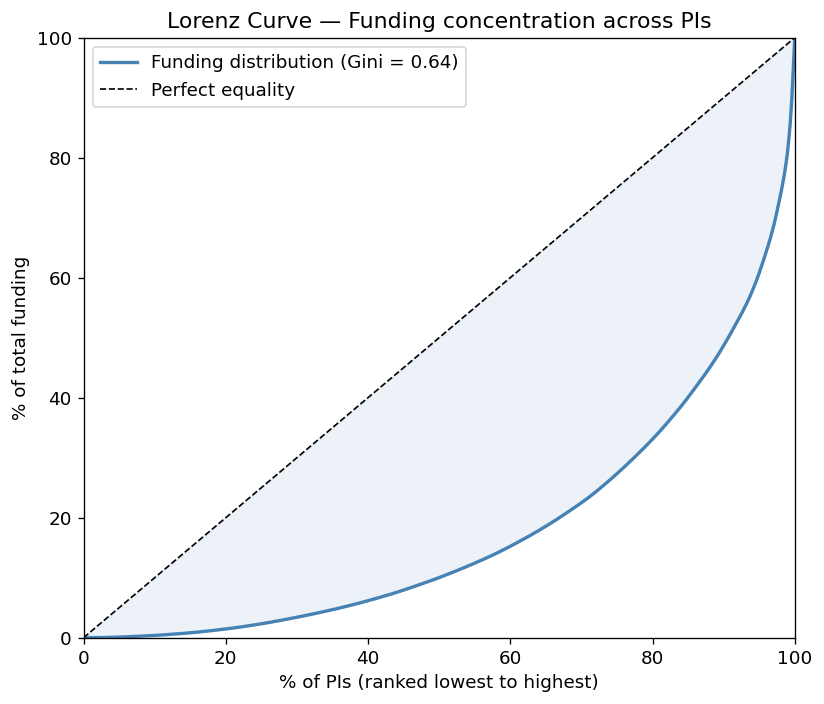

Gini coefficient: 0.643  (0 = perfect equality, 1 = one PI has everything)


In [41]:
# Lorenz curve — visualize funding inequality across PIs
# Diagonal = perfect equality; the further the curve bows down, the more concentrated funding is
sorted_funding = pi_funding.sort_values(ascending=True).values
n = len(sorted_funding)
lorenz_y = sorted_funding.cumsum() / sorted_funding.sum()
lorenz_x = np.arange(1, n+1) / n

# Gini coefficient
gini = 1 - 2 * np.trapz(lorenz_y, lorenz_x)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(lorenz_x * 100, lorenz_y * 100, color='steelblue', linewidth=2, label=f'Funding distribution (Gini = {gini:.2f})')
ax.plot([0, 100], [0, 100], 'k--', linewidth=1, label='Perfect equality')
ax.fill_between(lorenz_x * 100, lorenz_y * 100, lorenz_x * 100, alpha=0.1, color='steelblue')
ax.set_xlabel('% of PIs (ranked lowest to highest)')
ax.set_ylabel('% of total funding')
ax.set_title('Lorenz Curve — Funding concentration across PIs')
ax.legend()
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('./figures/lorenz_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Gini coefficient: {gini:.3f}  (0 = perfect equality, 1 = one PI has everything)')

# The x-axis is PIs ranked from lowest to highest funded (left = least funded, right = most funded)
# The y-axis is the cumulative share of total funding
# The diagonal line is what perfect equality would look like, the bottom 10% of PIs would hold 10% of money, bottom 50% would hold 50%, etc.
# Your actual curve bows below that diagonal, the further it bows, the more unequal the distribution

# The curve stays near zero for a long time (most PIs have very little) then shoots up steeply at the right end (a few PIs have a lot). 
# The area between the diagonal and the curve is what the Gini coefficient measure, bigger gap = higher Gini = more concentration.

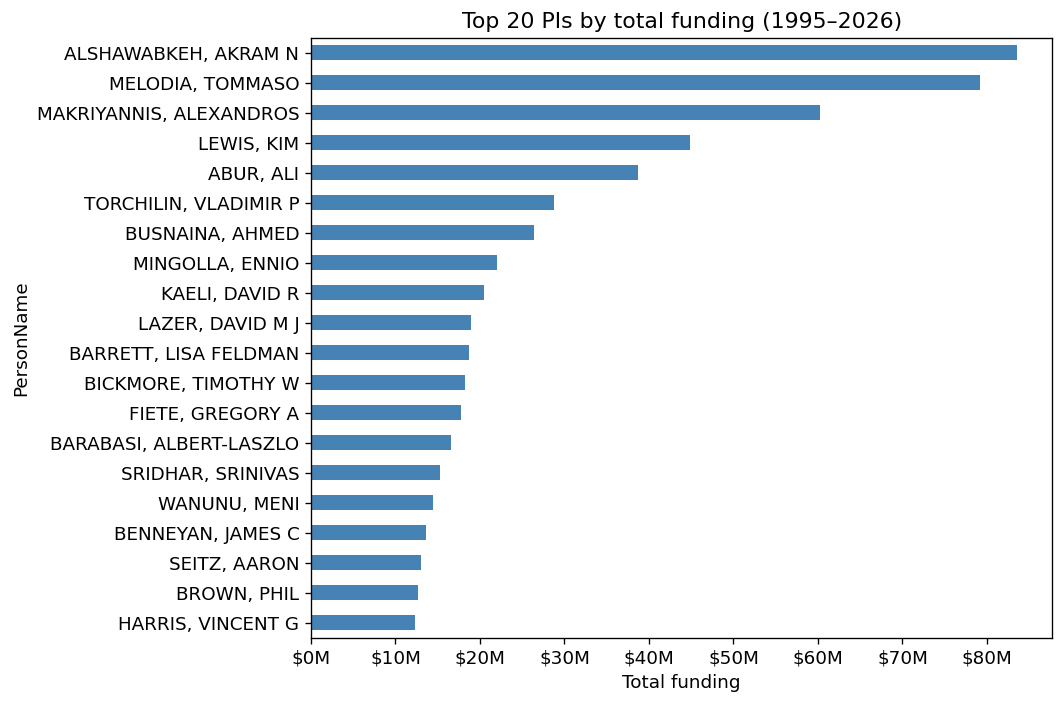

In [42]:
# Bar chart — top 20 PIs by total funding
top20 = pi_funding.head(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.set_xlabel('Total funding')
ax.set_title('Top 20 PIs by total funding (1995–2026)')
plt.tight_layout()
plt.savefig('./figures/top20_pis.png', dpi=150, bbox_inches='tight')
plt.show()

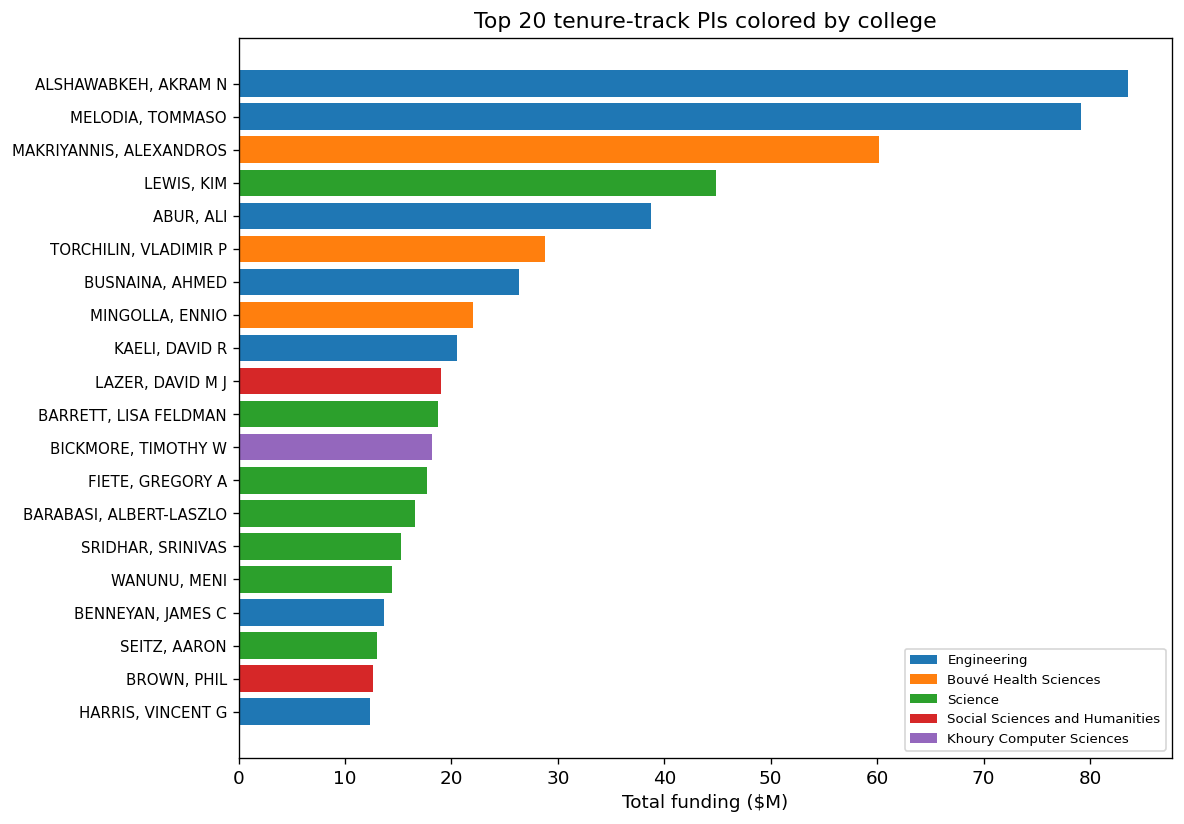

In [43]:
# Top 20 tenure-track PIs split by college — colored bar chart

copi_research = copi_with_college[copi_with_college['Academic Rank'].isin(research_ranks)].copy()
copi_tenure = copi_research[copi_research['Academic Track Type'] == 'Tenure Track'].copy()

top20_pi = (
    copi_tenure
    .groupby('PersonName')['TotalDollars']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top20_names   = top20_pi.index.tolist()
top20_details = copi_tenure[copi_tenure['PersonName'].isin(top20_names)].copy()

top20_college = (
    top20_details
    .groupby(['PersonName','Superior_Academic_Unit'])['TotalDollars']
    .sum()
    .reset_index()
    .sort_values('TotalDollars', ascending=False)
)

colleges = top20_college['Superior_Academic_Unit'].unique()
colors   = dict(zip(colleges, plt.cm.tab10.colors[:len(colleges)]))

fig, ax = plt.subplots(figsize=(10, 7))
for i, name in enumerate(top20_pi.sort_values().index):
    row = top20_college[top20_college['PersonName'] == name].iloc[0]
    color = colors[row['Superior_Academic_Unit']]
    ax.barh(i, row['TotalDollars']/1e6, color=color)

ax.set_yticks(range(len(top20_pi.sort_values())))
ax.set_yticklabels(top20_pi.sort_values().index, fontsize=9)
ax.set_xlabel('Total funding ($M)')
ax.set_title('Top 20 tenure-track PIs colored by college')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[c], label=c.replace('College of ','').replace('Khoury College of ','Khoury/'))
                   for c in colleges]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('./figures/top20_tenure_pi_by_college.png', dpi=150, bbox_inches='tight')
plt.show()

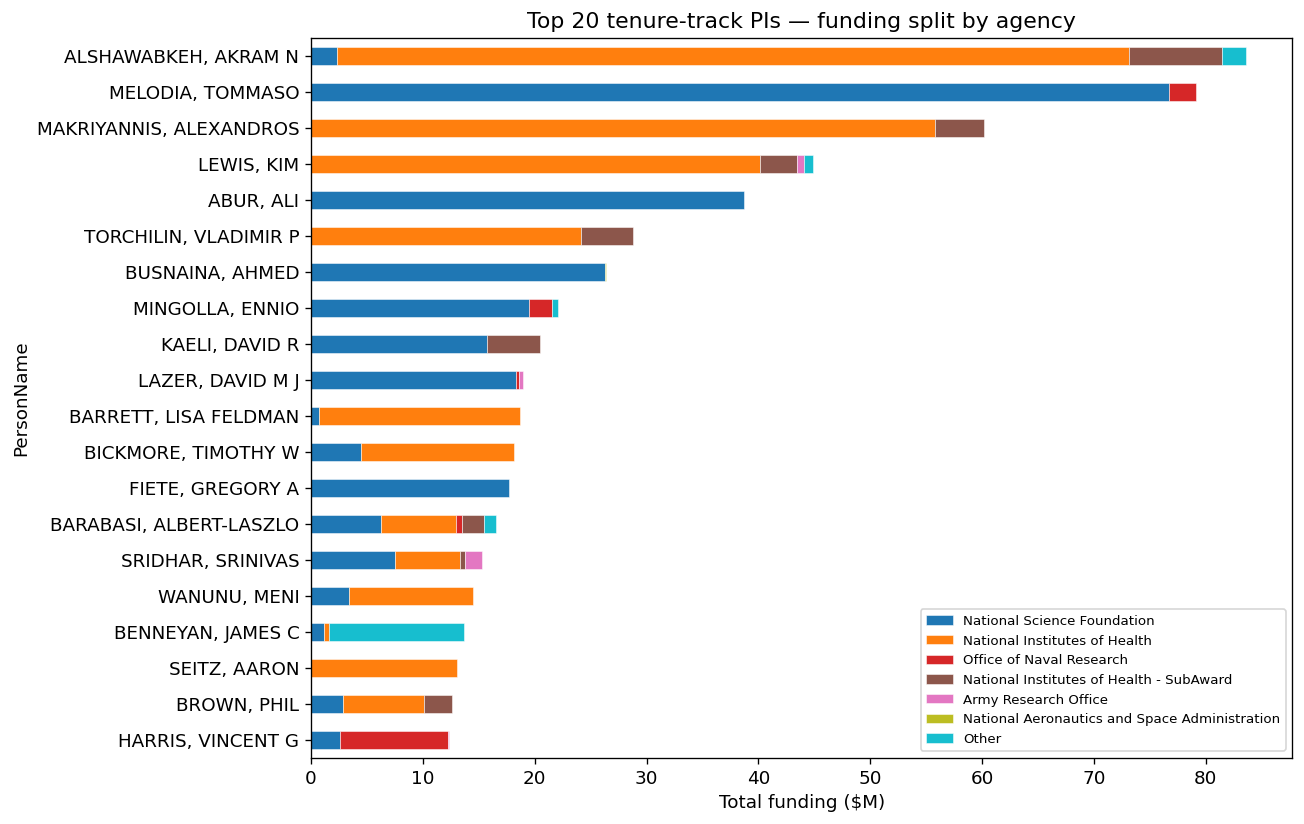

In [44]:
# Top 20 tenure-track PIs split by agency — stacked bar
top20_agency = (
    top20_details
    .groupby(['PersonName','AgencyName'])['TotalDollars']
    .sum()
    .unstack(fill_value=0)
)
# Keep top 6 agencies, group rest as 'Other'
top6_ag = copi_tenure['AgencyName'].value_counts().head(6).index
other_cols = [c for c in top20_agency.columns if c not in top6_ag]
top20_agency['Other'] = top20_agency[other_cols].sum(axis=1)
top20_agency = top20_agency[list(top6_ag) + ['Other']]
top20_agency = top20_agency.loc[top20_pi.sort_values().index]

fig, ax = plt.subplots(figsize=(11, 7))
(top20_agency / 1e6).plot(kind='barh', stacked=True, ax=ax,
                           colormap='tab10', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Total funding ($M)')
ax.set_title('Top 20 tenure-track PIs — funding split by agency')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('./figures/top20_tenure_pi_by_agency.png', dpi=150, bbox_inches='tight')
plt.show()

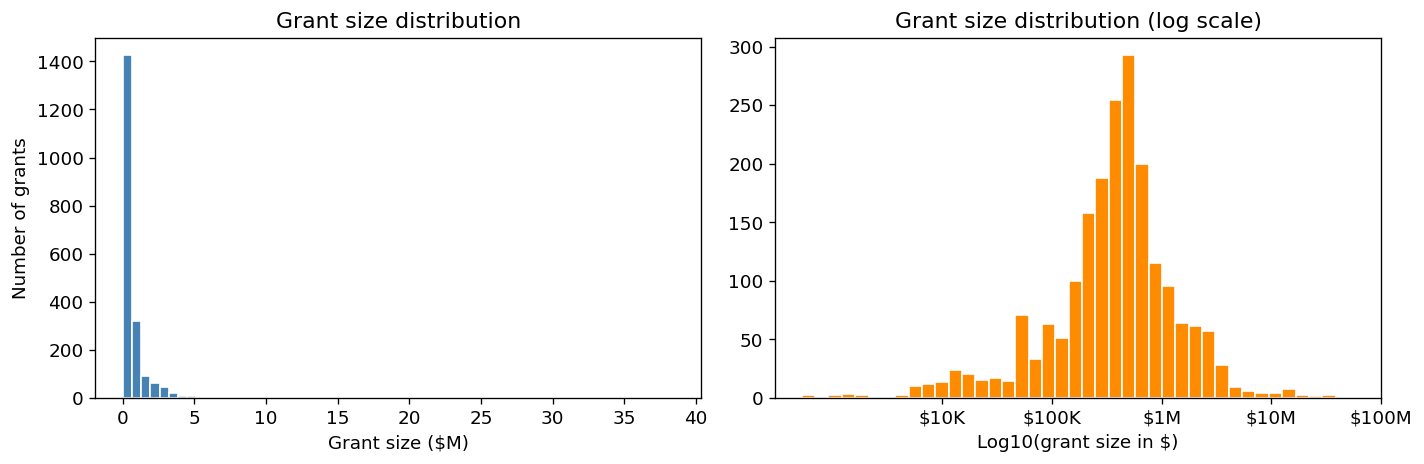

Grant size percentiles:
  10th percentile: $60,000
  25th percentile: $200,000
  50th percentile: $417,832
  75th percentile: $728,582
  90th percentile: $1,599,925
  95th percentile: $2,566,080
  99th percentile: $7,130,881


In [45]:
# Funding distribution histogram — what does a typical grant look like?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw distribution
axes[0].hist(copi_deduped['TotalDollars']/1e6, bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Grant size ($M)')
axes[0].set_ylabel('Number of grants')
axes[0].set_title('Grant size distribution')

# Log scale to see the full range
log_dollars = np.log10(copi_deduped['TotalDollars'].replace(0, np.nan).dropna())
axes[1].hist(log_dollars, bins=40, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Log10(grant size in $)')
axes[1].set_title('Grant size distribution (log scale)')
axes[1].set_xticks([4,5,6,7,8])
axes[1].set_xticklabels(['$10K','$100K','$1M','$10M','$100M'])

plt.tight_layout()
plt.savefig('./figures/grant_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Grant size percentiles:')
for p in [10, 25, 50, 75, 90, 95, 99]:
    val = np.percentile(copi_deduped['TotalDollars'], p)
    print(f'  {p}th percentile: ${val:,.0f}')

## 2. College-Level Analysis — Raw and Normalized

In [46]:
# Raw funding per college: total dollars, number of grants, average grant size
college_raw = (
    copi_with_college
    .groupby('Superior_Academic_Unit', dropna=True)['TotalDollars']
    .agg(['sum','count','mean','median'])
    .rename(columns={'sum':'total_dollars','count':'num_grants','mean':'avg_grant','median':'median_grant'})
    .sort_values('total_dollars', ascending=False)
)
college_raw['total_M'] = college_raw['total_dollars'] / 1e6
college_raw = college_raw[~college_raw.index.isin(['Northeastern University'])]
print('Raw funding by college:')
print(college_raw[['num_grants','total_M','avg_grant','median_grant']].to_string())

Raw funding by college:
                                           num_grants  total_M    avg_grant  median_grant
Superior_Academic_Unit                                                                   
College of Engineering                            784   643.58   820,888.35    383,886.00
College of Science                                582   445.57   765,581.95    432,552.00
Bouvé College of Health Sciences                  184   229.53 1,247,434.03    499,676.00
Khoury College of Computer Sciences               310   181.25   584,675.44    449,973.50
College of Social Sciences and Humanities          92    50.98   554,077.72    199,692.00
College of Arts, Media and Design                  33    23.02   697,487.76    527,350.00
School of Law                                       5     7.89 1,577,810.20  1,370,189.00
College of Professional Studies                     4     5.04 1,259,413.00  1,196,433.00
D'Amore-McKim School of Business                    7     2.30   328,842.14 

In [47]:
# Count faculty per college — exclude 'Northeastern University' placeholder
EXCLUDE_COLLEGES = ['Northeastern University']

faculty_per_college = (
    faculty[~faculty['Superior_Academic_Unit'].isin(EXCLUDE_COLLEGES)]
    .groupby('Superior_Academic_Unit').size()
    .rename('total_faculty')
)
tenure_per_college = (
    faculty[
        (faculty['Academic Track Type'] == 'Tenure Track') &
        (~faculty['Superior_Academic_Unit'].isin(EXCLUDE_COLLEGES))
    ]
    .groupby('Superior_Academic_Unit').size()
    .rename('tenure_faculty')
)

print('Faculty per college (all tracks):')
print(faculty_per_college.sort_values(ascending=False).to_string())
print()
print('Tenure-track faculty per college:')
print(tenure_per_college.sort_values(ascending=False).to_string())
print()

# Normalize funding by faculty count
college_norm = college_raw.join(faculty_per_college).join(tenure_per_college)
college_norm = college_norm[~college_norm.index.isin(EXCLUDE_COLLEGES)]

college_norm['dollars_per_faculty'] = college_norm['total_dollars'] / college_norm['total_faculty']
college_norm['dollars_per_tenure']  = college_norm['total_dollars'] / college_norm['tenure_faculty']
college_norm['grants_per_faculty']  = college_norm['num_grants']    / college_norm['total_faculty']
college_norm['grants_per_tenure']   = college_norm['num_grants']    / college_norm['tenure_faculty']

print('Normalized metrics per college:')
print(college_norm[['total_faculty','tenure_faculty','num_grants','total_M',
                     'dollars_per_faculty','dollars_per_tenure','grants_per_tenure']]
      .sort_values('dollars_per_tenure', ascending=False).to_string())

Faculty per college (all tracks):
Superior_Academic_Unit
College of Engineering                       356
College of Science                           332
College of Social Sciences and Humanities    304
Bouvé College of Health Sciences             269
D'Amore-McKim School of Business             215
College of Arts, Media and Design            210
Khoury College of Computer Sciences          210
Northeastern University London               126
College of Professional Studies              110
School of Law                                 58
Mills College at Northeastern                 40

Tenure-track faculty per college:
Superior_Academic_Unit
College of Engineering                       207
College of Science                           172
College of Social Sciences and Humanities    152
College of Arts, Media and Design            103
D'Amore-McKim School of Business              93
Bouvé College of Health Sciences              87
Khoury College of Computer Sciences           80
Sch

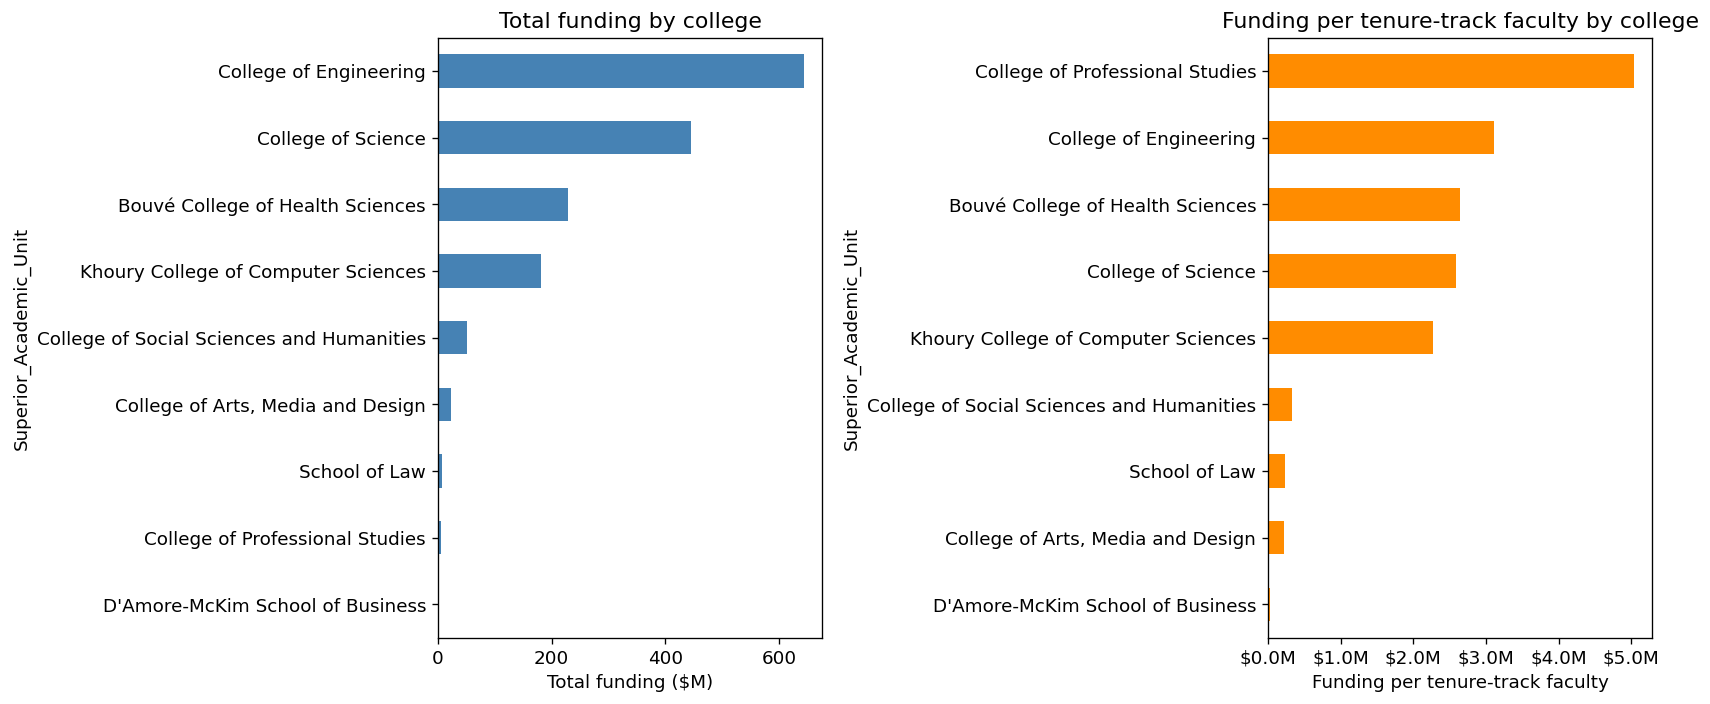

In [48]:
# Side-by-side: raw total funding vs funding per tenure-track faculty
# This reveals colleges that look small in absolute terms but are actually productive per person
plot_df = college_norm.dropna(subset=['dollars_per_tenure']).sort_values('total_M', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_df['total_M'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Total funding ($M)')
axes[0].set_title('Total funding by college')

plot_df.sort_values('dollars_per_tenure', ascending=True)['dollars_per_tenure'].plot(
    kind='barh', ax=axes[1], color='darkorange')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].set_xlabel('Funding per tenure-track faculty')
axes[1].set_title('Funding per tenure-track faculty by college')

plt.tight_layout()
plt.savefig('./figures/college_funding_raw_vs_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

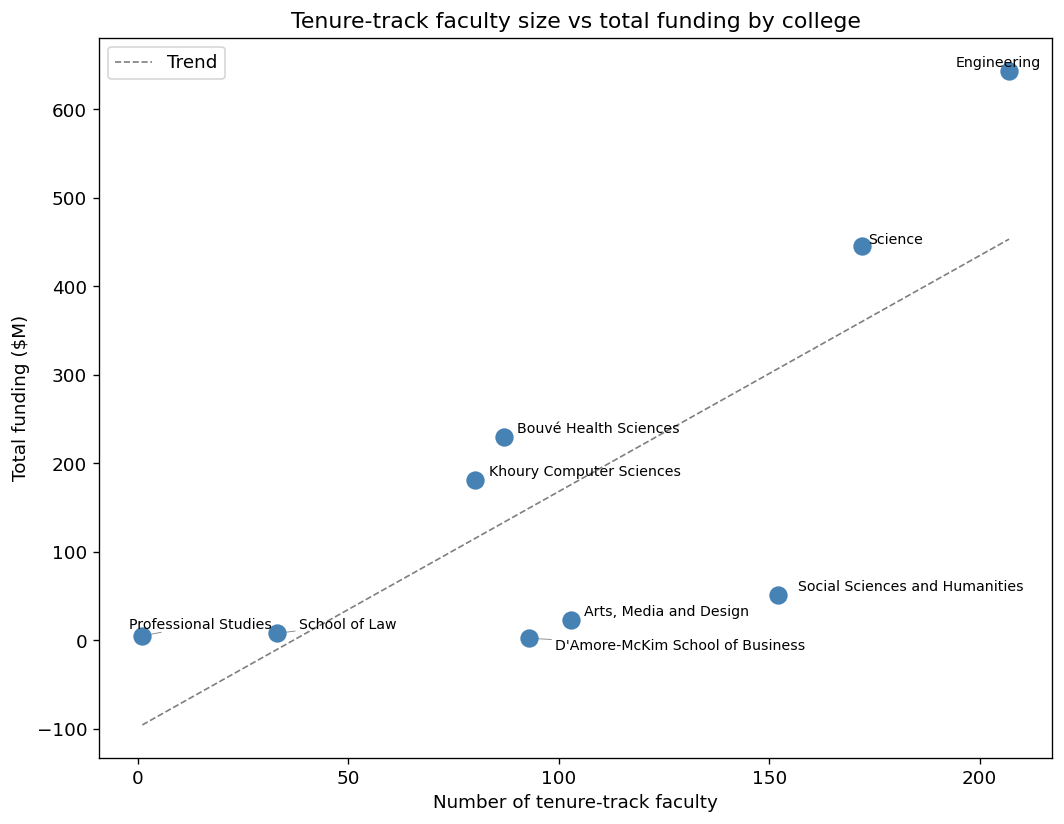

In [49]:
# Scatter: tenure-track faculty count vs total funding per college
# Shows which colleges are above/below the trend line
# Auto-adjust labels to avoid overlap using adjustText

from adjustText import adjust_text

plot_df2 = college_norm.dropna(subset=['tenure_faculty','total_M']).copy()

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(plot_df2['tenure_faculty'], plot_df2['total_M'], s=100, color='steelblue', zorder=3)

texts = []
for _, row in plot_df2.iterrows():
    label = row.name.replace('College of ','').replace('Khoury College of ','Khoury/')
    t = ax.text(row['tenure_faculty'], row['total_M'], label, fontsize=8.5)
    texts.append(t)

adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Trend line
z = np.polyfit(plot_df2['tenure_faculty'], plot_df2['total_M'], 1)
p = np.poly1d(z)
x_line = np.linspace(plot_df2['tenure_faculty'].min(), plot_df2['tenure_faculty'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', linewidth=1, alpha=0.5, label='Trend')

# # Trend line — clip to data range, no extrapolation below zero
# z = np.polyfit(plot_df2['tenure_faculty'], plot_df2['total_M'], 1)
# p = np.poly1d(z)

# # start x_line at the smallest actual x value, not at 0
# x_min = plot_df2['tenure_faculty'].min()
# x_max = plot_df2['tenure_faculty'].max()
# x_line = np.linspace(x_min, x_max, 100)

# ax.plot(x_line, p(x_line), 'k--', linewidth=1, alpha=0.5, label='Trend')
# ax.set_ylim(bottom=0)  # no negative y axis

ax.set_xlabel('Number of tenure-track faculty')
ax.set_ylabel('Total funding ($M)')
ax.set_title('Tenure-track faculty size vs total funding by college')
ax.legend()
plt.tight_layout()
plt.savefig('./figures/college_scatter_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Funding Agency Analysis

In [50]:
# Full agency breakdown: grant count, total funding, average grant
agency_summary = (
    copi_deduped
    .groupby('AgencyName')['TotalDollars']
    .agg(['count','sum','mean'])
    .rename(columns={'count':'num_grants','sum':'total_dollars','mean':'avg_grant'})
    .sort_values('num_grants', ascending=False)
)
agency_summary['total_M']    = agency_summary['total_dollars'] / 1e6
agency_summary['pct_grants'] = (agency_summary['num_grants'] / agency_summary['num_grants'].sum() * 100).round(1)
agency_summary['pct_dollars'] = (agency_summary['total_dollars'] / agency_summary['total_dollars'].sum() * 100).round(1)

print(agency_summary[['num_grants','pct_grants','total_M','pct_dollars','avg_grant']].to_string())

                                                        num_grants  pct_grants  total_M  pct_dollars    avg_grant
AgencyName                                                                                                       
National Science Foundation                                   1294       64.60   819.07        51.50   632,977.41
National Institutes of Health                                  393       19.60   580.04        36.50 1,475,919.77
Office of Naval Research                                        65        3.20    41.42         2.60   637,249.38
National Institutes of Health - SubAward                        63        3.10    45.76         2.90   726,275.29
National Aeronautics and Space Administration                   42        2.10    19.40         1.20   461,787.76
Army Research Office                                            33        1.60     9.19         0.60   278,552.36
Department Of Energy                                            26        1.30    24.19 

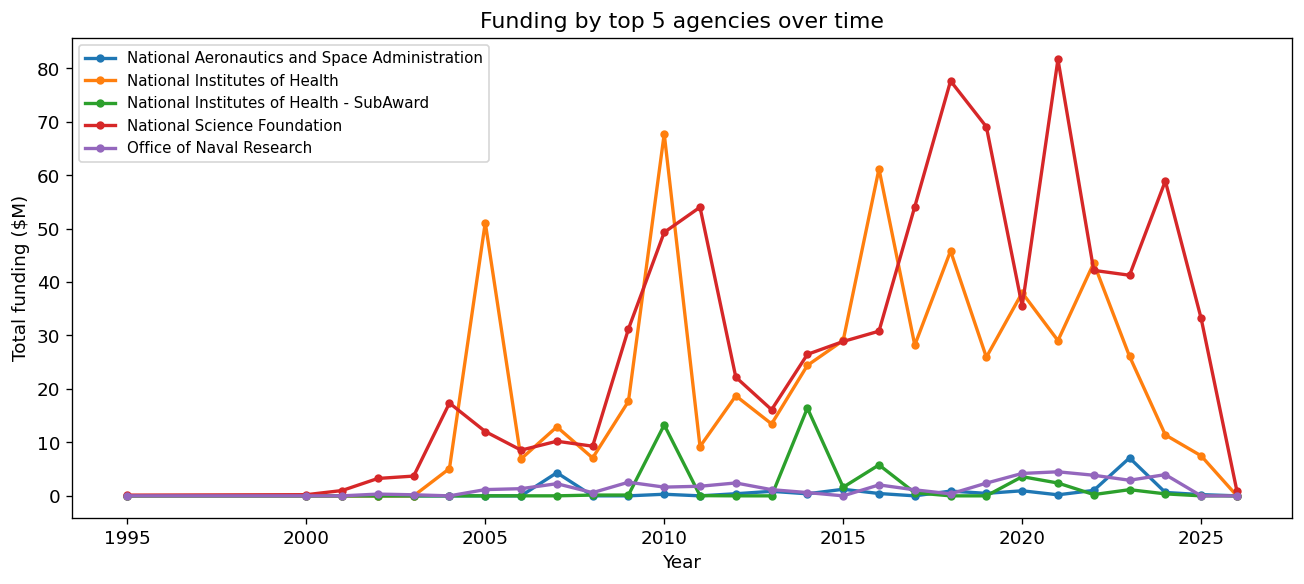

In [51]:
# Agency funding trend over time — top 5 agencies
top5_agencies = agency_summary.head(5).index.tolist()

agency_year = (
    copi_deduped[copi_deduped['AgencyName'].isin(top5_agencies)]
    .groupby(['StartDateYear','AgencyName'])['TotalDollars']
    .sum()
    .unstack(fill_value=0)
) / 1e6

fig, ax = plt.subplots(figsize=(11, 5))
agency_year.plot(ax=ax, linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Total funding ($M)')
ax.set_title('Funding by top 5 agencies over time')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('./figures/agency_trend.png', dpi=150, bbox_inches='tight')
plt.show()

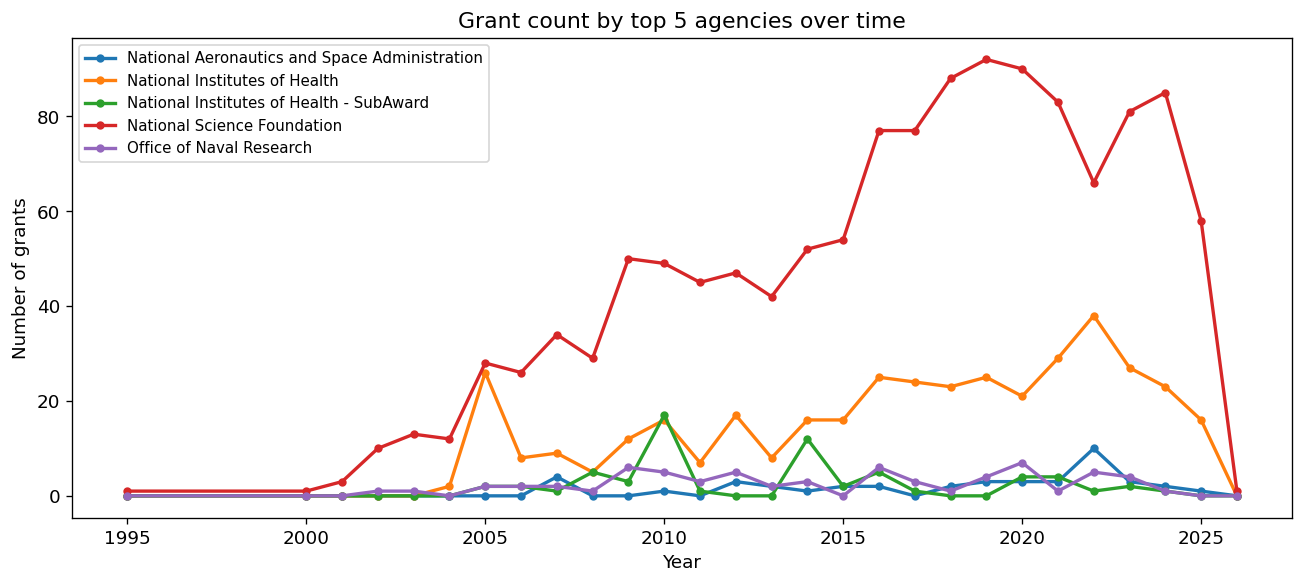

In [52]:
# Agency grant count trend over time — same top 5
agency_year_count = (
    copi_deduped[copi_deduped['AgencyName'].isin(top5_agencies)]
    .groupby(['StartDateYear','AgencyName'])['GrantId']
    .count()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 5))
agency_year_count.plot(ax=ax, linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Number of grants')
ax.set_title('Grant count by top 5 agencies over time')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('./figures/agency_count_trend.png', dpi=150, bbox_inches='tight')
plt.show()

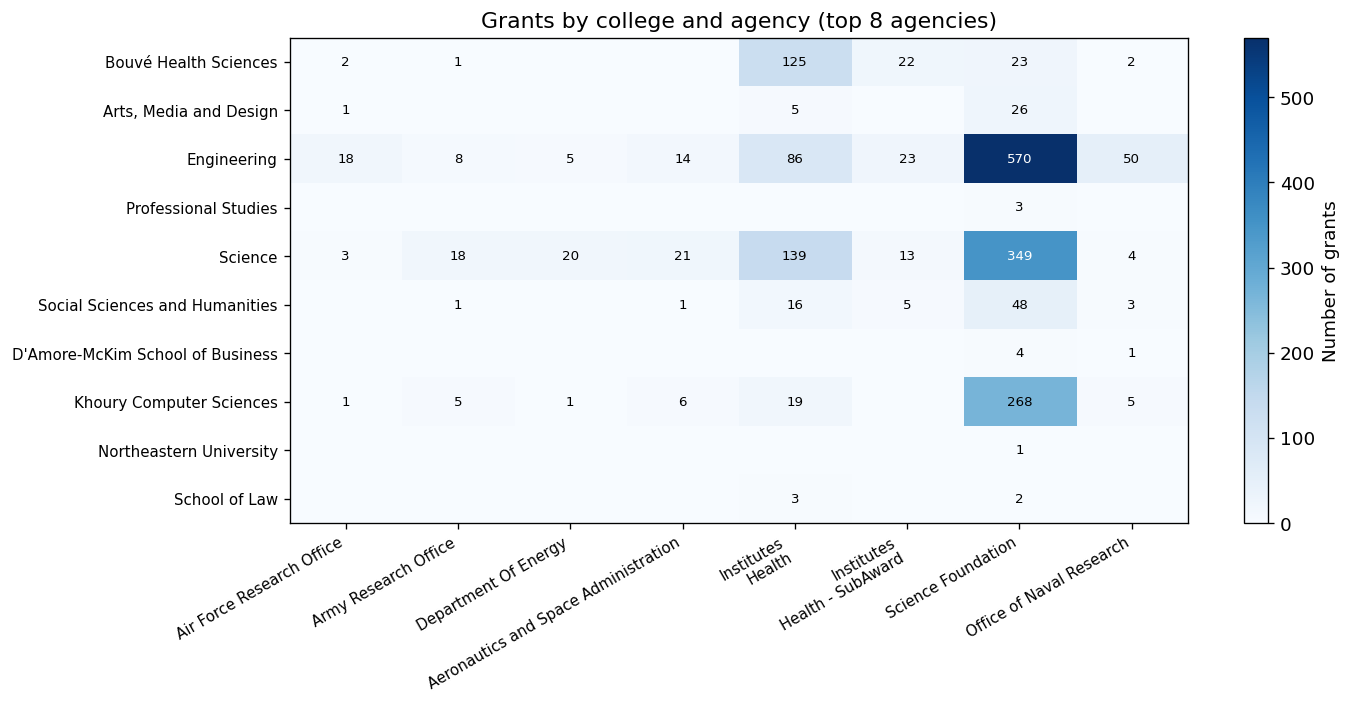

In [53]:
# Heatmap: college x agency — number of grants
college_agency = (
    copi_with_college
    .dropna(subset=['Superior_Academic_Unit'])
    .groupby(['Superior_Academic_Unit','AgencyName'])['GrantId']
    .count()
    .unstack(fill_value=0)
)
# Keep only top 8 agencies for readability
top8_agencies = agency_summary.head(8).index
college_agency_top = college_agency[college_agency.columns.intersection(top8_agencies)]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(college_agency_top.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(college_agency_top.columns)))
ax.set_xticklabels([c.replace('National ','').replace(' of Health','\nHealth') 
                    for c in college_agency_top.columns], rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(college_agency_top.index)))
ax.set_yticklabels([c.replace('College of ','').replace('Khoury College of ','') 
                    for c in college_agency_top.index], fontsize=9)
plt.colorbar(im, ax=ax, label='Number of grants')
ax.set_title('Grants by college and agency (top 8 agencies)')

# Add numbers in cells
for i in range(len(college_agency_top.index)):
    for j in range(len(college_agency_top.columns)):
        val = college_agency_top.values[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center', fontsize=8,
                    color='white' if val > college_agency_top.values.max()*0.5 else 'black')

plt.tight_layout()
plt.savefig('./figures/heatmap_college_agency.png', dpi=150, bbox_inches='tight')
plt.show()

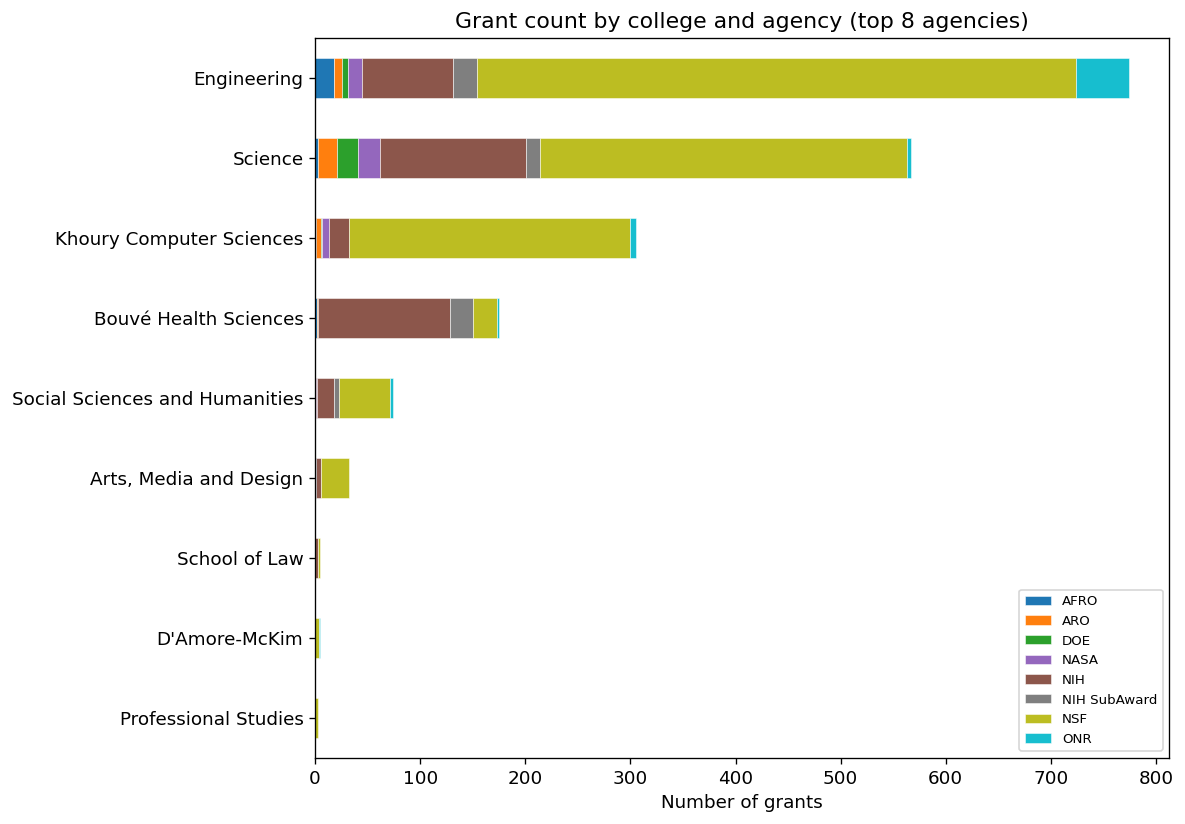

In [54]:
# Stacked bar — grant count per college split by agency
college_agency = (
    copi_with_college
    .dropna(subset=['Superior_Academic_Unit'])
    .groupby(['Superior_Academic_Unit', 'AgencyName'])['GrantId']
    .count()
    .unstack(fill_value=0)
)

# remove placeholder college
college_agency = college_agency[~college_agency.index.isin(['Northeastern University'])]


#shorten names
short_colleges = {c: c.replace('College of ', '').replace('Khoury College of ', 'Khoury/')
                       .replace('Bouvé College of ', 'Bouvé/')
                       .replace("D'Amore-McKim School of Business", "D'Amore-McKim")
                       .replace('Northeastern University London', 'NU London')
                       .replace('Mills College at Northeastern', 'Mills')
                  for c in college_agency.index}
short_agencies = {c: c.replace('National Science Foundation', 'NSF')
                       .replace('National Institutes of Health - SubAward', 'NIH SubAward')
                       .replace('National Institutes of Health', 'NIH')
                       .replace('Office of Naval Research', 'ONR')
                       .replace('National Aeronautics and Space Administration', 'NASA')
                       .replace('Army Research Office', 'ARO')
                       .replace('Department Of Energy', 'DOE')
                       .replace('Air Force Research Office', 'AFRO')
                  for c in college_agency.columns}

top8_agencies = agency_summary.head(8).index
ca            = college_agency[college_agency.columns.intersection(top8_agencies)].copy()
ca.index      = [short_colleges.get(c, c) for c in ca.index]
ca.columns    = [short_agencies.get(c, c) for c in ca.columns]

fig, ax = plt.subplots(figsize=(10, 7))
ca = ca.loc[ca.sum(axis=1).sort_values(ascending=True).index]
ca.plot(kind='barh', stacked=True, ax=ax, colormap='tab10',
        edgecolor='white', linewidth=0.3)
ax.set_xlabel('Number of grants')
ax.set_title('Grant count by college and agency (top 8 agencies)')
ax.legend(fontsize=8, loc='lower right')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('./figures/college_agency_chart.png', dpi=150, bbox_inches='tight')
plt.show()

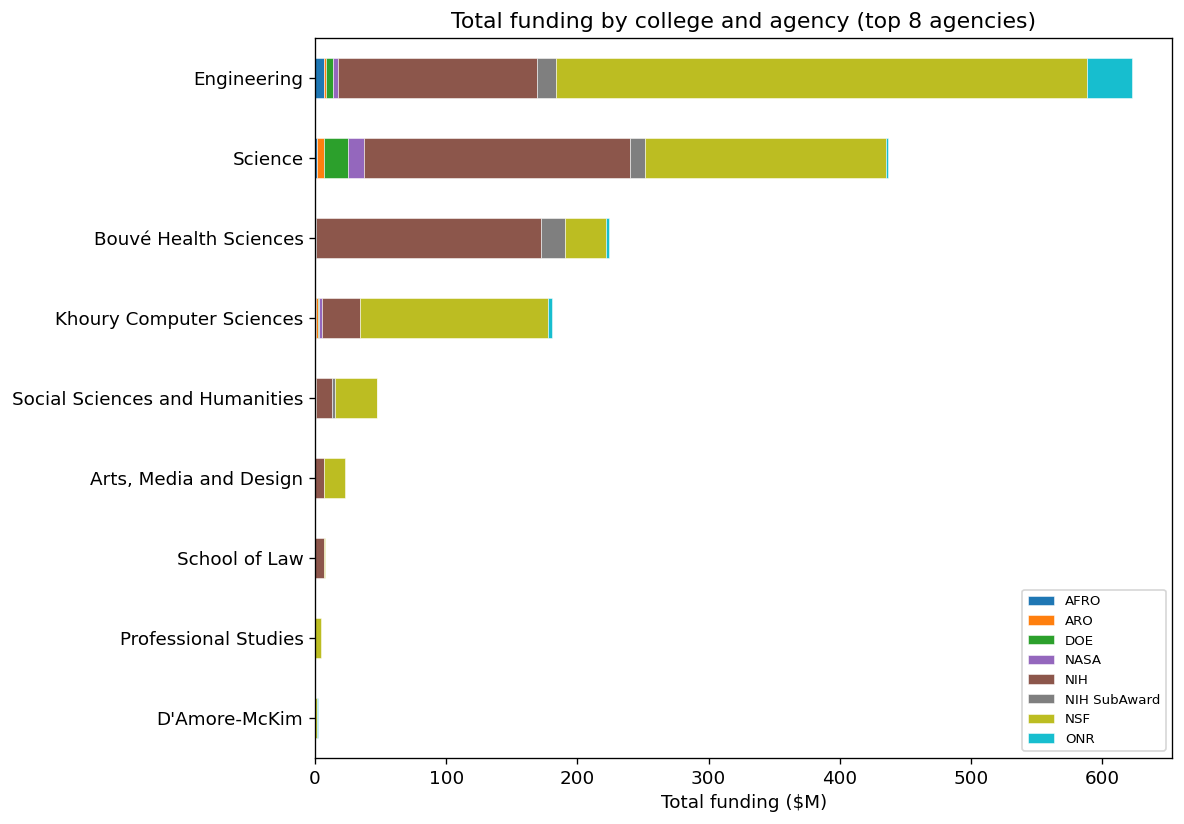

In [55]:
# same chart but by total funding amount instead of grant count
ca_dollars = (
    copi_with_college
    .dropna(subset=['Superior_Academic_Unit'])
    .query('Superior_Academic_Unit != "Northeastern University"')
    .groupby(['Superior_Academic_Unit', 'AgencyName'])['TotalDollars']
    .sum()
    .unstack(fill_value=0)
)

ca_dollars = ca_dollars[ca_dollars.columns.intersection(top8_agencies)].copy()
ca_dollars.index   = [short_colleges.get(c, c) for c in ca_dollars.index]
ca_dollars.columns = [short_agencies.get(c, c) for c in ca_dollars.columns]
ca_dollars = ca_dollars.loc[ca_dollars.sum(axis=1).sort_values(ascending=True).index]
ca_dollars_M = ca_dollars / 1e6

fig, ax = plt.subplots(figsize=(10, 7))
ca_dollars_M.plot(kind='barh', stacked=True, ax=ax, colormap='tab10',
                   edgecolor='white', linewidth=0.3)
ax.set_xlabel('Total funding ($M)')
ax.set_title('Total funding by college and agency (top 8 agencies)')
ax.legend(fontsize=8, loc='lower right')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('./figures/college_agency_dollars.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Funding Over Time

In [56]:
# Total grants and funding per year
grants_per_year  = copi_deduped.groupby('StartDateYear')['GrantId'].count().rename('num_grants')
dollars_per_year = copi_deduped.groupby('StartDateYear')['TotalDollars'].sum().rename('total_dollars') / 1e6
avg_per_year     = (copi_deduped.groupby('StartDateYear')['TotalDollars'].mean() / 1e6).rename('avg_grant_M')

yearly = pd.concat([grants_per_year, dollars_per_year, avg_per_year], axis=1)
print(yearly.to_string())

               num_grants  total_dollars  avg_grant_M
StartDateYear                                        
1995                    1           0.13         0.13
2000                    1           0.21         0.21
2001                    3           1.00         0.33
2002                   12           5.15         0.43
2003                   14           3.90         0.28
2004                   16          23.24         1.45
2005                   59          64.92         1.10
2006                   40          17.61         0.44
2007                   55          34.51         0.63
2008                   44          19.56         0.44
2009                   80          53.92         0.67
2010                   93         133.63         1.44
2011                   63          68.18         1.08
2012                   80          55.95         0.70
2013                   58          32.60         0.56
2014                   93          77.11         0.83
2015                   84   

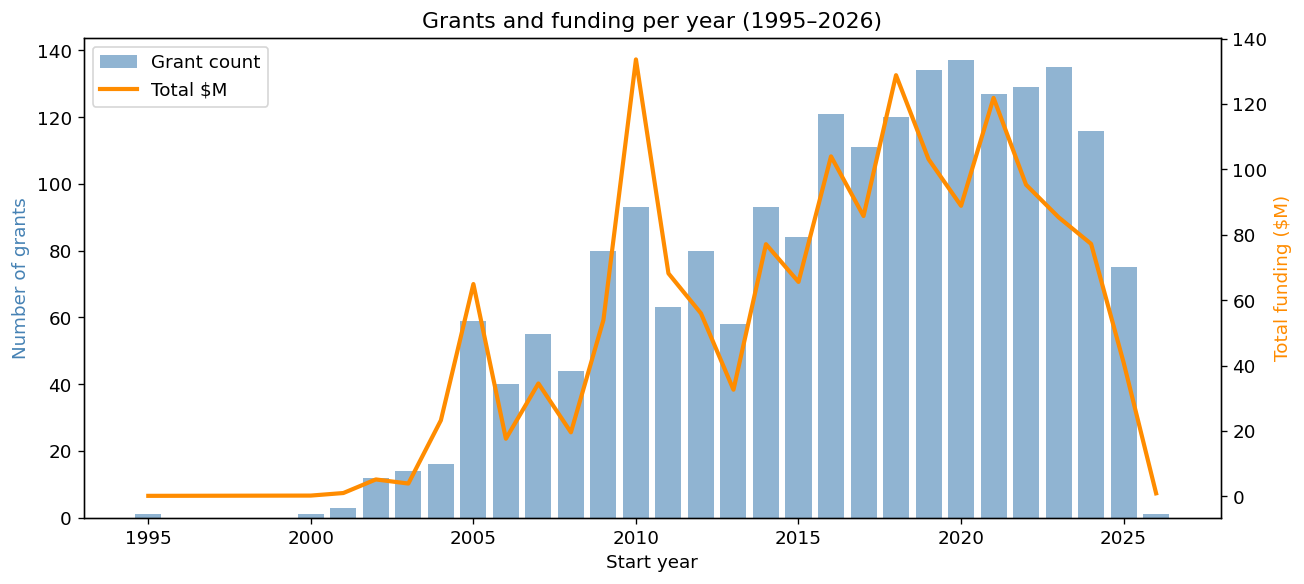

In [57]:
# Dual-axis chart: grant count and total dollars per year
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.bar(grants_per_year.index, grants_per_year.values, color='steelblue', alpha=0.6, label='Grant count')
ax2.plot(dollars_per_year.index, dollars_per_year.values, color='darkorange', linewidth=2.5, label='Total $M')

ax1.set_xlabel('Start year')
ax1.set_ylabel('Number of grants', color='steelblue')
ax2.set_ylabel('Total funding ($M)', color='darkorange')
ax1.set_title('Grants and funding per year (1995–2026)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('./figures/funding_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Co-PI Structure

In [58]:
# PI vs co-PI: count and funding comparison
role_summary = (
    copi_deduped
    .groupby('IsCoPI')['TotalDollars']
    .agg(['count','mean','median','sum'])
    .rename(index={0:'PI', 1:'Co-PI'})
)
role_summary['sum_M'] = role_summary['sum'] / 1e6

print('PI vs Co-PI comparison (pre-dedup, all rows):')
print(role_summary[['count','mean','median','sum_M']].to_string())

# TotalDollars is the same value for all people on one grant
# Co-PI grants appear larger because they are more often large collaborative projects.

PI vs Co-PI comparison (pre-dedup, all rows):
        count         mean     median    sum_M
IsCoPI                                        
PI       1822   738,987.64 404,666.00 1,346.44
Co-PI     180 1,348,653.56 530,352.00   242.76


In [59]:
# How many grants involve a co-PI vs are solo PI grants?
grants_with_copi_deduped = copi_deduped[copi_deduped['IsCoPI']==1]['GrantId'].nunique()
grants_solo      = copi_deduped['GrantId'].nunique() - grants_with_copi_deduped

print(f'Total unique grants              : {copi_deduped["GrantId"].nunique():,}')
print(f'Grants with at least one co-PI   : {grants_with_copi_deduped:,}  ({grants_with_copi_deduped/copi_deduped["GrantId"].nunique()*100:.1f}%)')
print(f'Solo PI grants (no co-PI)        : {grants_solo:,}  ({grants_solo/copi_deduped["GrantId"].nunique()*100:.1f}%)')

# Average grant size: collaborative vs solo
collab_grants = copi_deduped[copi_deduped['GrantId'].isin(copi[copi['IsCoPI']==1]['GrantId'])]
solo_grants   = copi_deduped[~copi_deduped['GrantId'].isin(copi[copi['IsCoPI']==1]['GrantId'])]

print()
print(f'Avg grant size — collaborative   : ${collab_grants["TotalDollars"].mean():,.0f}')
print(f'Avg grant size — solo PI         : ${solo_grants["TotalDollars"].mean():,.0f}')
print(f'Median — collaborative           : ${collab_grants["TotalDollars"].median():,.0f}')
print(f'Median — solo PI                 : ${solo_grants["TotalDollars"].median():,.0f}')

Total unique grants              : 2,002
Grants with at least one co-PI   : 180  (9.0%)
Solo PI grants (no co-PI)        : 1,822  (91.0%)

Avg grant size — collaborative   : $1,056,723
Avg grant size — solo PI         : $716,693
Median — collaborative           : $523,522
Median — solo PI                 : $386,529


In [60]:
# People who mostly appear as co-PIs vs leads
# For each person: what % of their grants are as co-PI?
person_roles = (
    copi_deduped
    .groupby('PersonName')['IsCoPI']
    .agg(['sum','count'])
    .rename(columns={'sum':'copi_count','count':'total_grants'})
)
person_roles['pct_copi'] = person_roles['copi_count'] / person_roles['total_grants'] * 100

always_copi  = person_roles[person_roles['pct_copi'] == 100]
mostly_copi  = person_roles[(person_roles['pct_copi'] >= 50) & (person_roles['pct_copi'] < 100)]
mostly_pi    = person_roles[person_roles['pct_copi'] == 0]

print(f'People who are always co-PI (never lead)  : {len(always_copi)}')
print(f'People who are mostly co-PI (>=50%)       : {len(mostly_copi)}')
print(f'People who are always lead PI             : {len(mostly_pi)}')
print()
print('Always co-PI people (sample):')
print(always_copi.sort_values('total_grants', ascending=False).head(10).to_string())

People who are always co-PI (never lead)  : 10
People who are mostly co-PI (>=50%)       : 21
People who are always lead PI             : 364

Always co-PI people (sample):
                         copi_count  total_grants  pct_copi
PersonName                                                 
OWENS, JANE                       3             3    100.00
WELLES, BROOKE FOUCAULT           2             2    100.00
BELETSKY, LEO                     1             1    100.00
CONN, KELLY                       1             1    100.00
HUTCHINSON, SETH                  1             1    100.00
KUHL, LAURA N                     1             1    100.00
LESKO, JACK JAMES                 1             1    100.00
MADIGAN, DAVID BENNETT            1             1    100.00
TORY, MELANIE KARLA               1             1    100.00
WINSLOW, RAI LESTER               1             1    100.00


Co-PI rate by college:
                                           total_rows  copi_pct
Superior_Academic_Unit                                         
College of Professional Studies                     4     50.00
College of Arts, Media and Design                  60     48.30
Northeastern University                             6     33.30
School of Law                                      12     33.30
College of Social Sciences and Humanities         142     31.70
D'Amore-McKim School of Business                   11     27.30
Khoury College of Computer Sciences               421     25.90
College of Engineering                           1145     25.50
College of Science                                870     21.60
Bouvé College of Health Sciences                  288     12.50


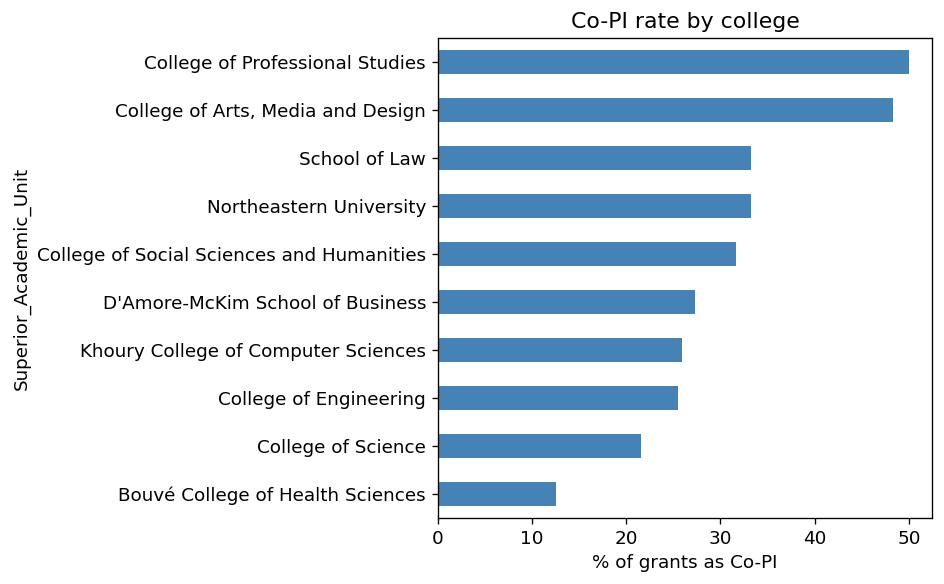

In [61]:
# Co-PI rate by college — which colleges collaborate more?
copi_by_college = (
    copi.merge(faculty_slim, on='ClientFacultyId', how='left')
    .dropna(subset=['Superior_Academic_Unit'])
    .groupby('Superior_Academic_Unit')['IsCoPI']
    .agg(['mean','count'])
    .rename(columns={'mean':'copi_rate','count':'total_rows'})
    .sort_values('copi_rate', ascending=False)
)
copi_by_college['copi_pct'] = (copi_by_college['copi_rate'] * 100).round(1)

print('Co-PI rate by college:')
print(copi_by_college[['total_rows','copi_pct']].to_string())

fig, ax = plt.subplots(figsize=(8, 5))
copi_by_college['copi_pct'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% of grants as Co-PI')
ax.set_title('Co-PI rate by college')
plt.tight_layout()
plt.savefig('./figures/copi_rate_college.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Gap Analysis — Funded vs Unfunded Faculty

In [62]:
# Which current tenure-track faculty have no grants in the dataset?
tenure_faculty = faculty[faculty['Academic Track Type'] == 'Tenure Track'].copy()
funded_ids     = set(copi_deduped['ClientFacultyId'].values)

tenure_faculty['has_grant'] = tenure_faculty['Employee ID'].isin(funded_ids)

funded_count   = tenure_faculty['has_grant'].sum()
unfunded_count = (~tenure_faculty['has_grant']).sum()

print(f'Tenure-track faculty total : {len(tenure_faculty):,}')
print(f'  With grant records       : {funded_count:,}  ({funded_count/len(tenure_faculty)*100:.1f}%)')
print(f'  No grant record          : {unfunded_count:,}  ({unfunded_count/len(tenure_faculty)*100:.1f}%)')

Tenure-track faculty total : 958
  With grant records       : 463  (48.3%)
  No grant record          : 495  (51.7%)


Funded vs unfunded tenure-track faculty per college:


                                           funded  total  unfunded  funded_pct  unfunded_pct
Superior_Academic_Unit                                                                      
College of Professional Studies                 1      1         0      100.00          0.00
Northeastern University                         1      1         0      100.00          0.00
Khoury College of Computer Sciences            64     80        16       80.00         20.00
College of Engineering                        161    207        46       77.80         22.20
College of Science                            128    172        44       74.40         25.60
Bouvé College of Health Sciences               49     87        38       56.30         43.70
College of Social Sciences and Humanities      35    152       117       23.00         77.00
College of Arts, Media and Design              15    103        88       14.60         85.40
School of Law                                   4     33        29   

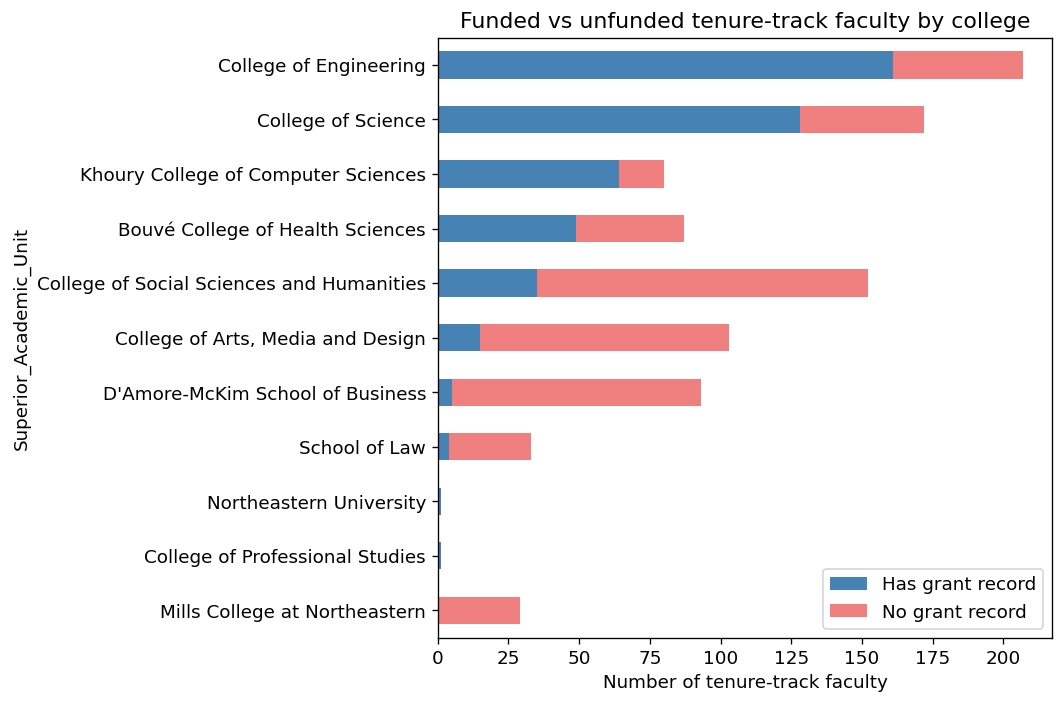

In [63]:

# Funded vs unfunded tenure-track faculty per college
gap_by_college = (
    tenure_faculty
    .groupby('Superior_Academic_Unit')['has_grant']
    .agg(['sum','count'])
    .rename(columns={'sum':'funded','count':'total'})
)
gap_by_college['unfunded']    = gap_by_college['total'] - gap_by_college['funded']
gap_by_college['funded_pct']  = (gap_by_college['funded']   / gap_by_college['total'] * 100).round(1)
gap_by_college['unfunded_pct'] = (gap_by_college['unfunded'] / gap_by_college['total'] * 100).round(1)
gap_by_college = gap_by_college.sort_values('funded_pct', ascending=False)

print('Funded vs unfunded tenure-track faculty per college:')
print(gap_by_college.to_string())

# Stacked bar
fig, ax = plt.subplots(figsize=(9, 6))

gap_plot = gap_by_college[['funded', 'unfunded']].copy()
gap_plot = gap_plot.sort_values('funded', ascending=True)
gap_plot.columns = ['Has grant record', 'No grant record']

gap_plot.plot(kind='barh', stacked=True, ax=ax,
              color=['steelblue', 'lightcoral'])

ax.set_xlabel('Number of tenure-track faculty')
ax.set_title('Funded vs unfunded tenure-track faculty by college')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('./figures/gap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Grants per funded tenure-track PI:
count   481.00
mean      4.16
std       3.92
min       1.00
25%       1.00
50%       3.00
75%       5.00
max      27.00
Name: num_grants, dtype: float64

Distribution:
  >=  1 grants : 481 people
  >=  2 grants : 359 people
  >=  5 grants : 155 people
  >= 10 grants : 46 people
  >= 20 grants : 4 people


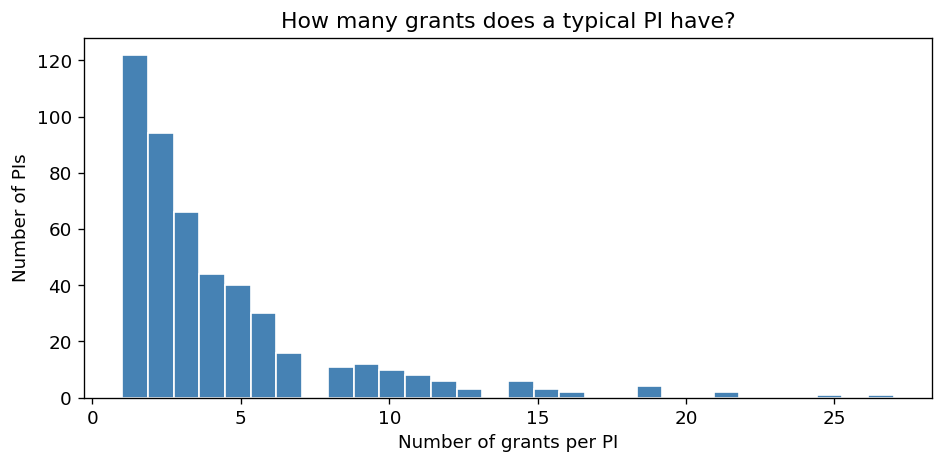

In [64]:
# Among funded tenure-track faculty: distribution of number of grants per person
grants_per_person = (
    copi_deduped
    .groupby('ClientFacultyId')['GrantId']
    .count()
    .rename('num_grants')
)

print('Grants per funded tenure-track PI:')
print(grants_per_person.describe())
print()
print('Distribution:')
for threshold in [1, 2, 5, 10, 20]:
    n = (grants_per_person >= threshold).sum()
    print(f'  >= {threshold:2d} grants : {n} people')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(grants_per_person.values, bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of grants per PI')
ax.set_ylabel('Number of PIs')
ax.set_title('How many grants does a typical PI have?')
plt.tight_layout()
plt.savefig('./figures/grants_per_pi.png', dpi=150, bbox_inches='tight')
plt.show()

Grants per funded tenure-track PI (all ranks):
count   462.00
mean      4.25
std       3.95
min       1.00
25%       2.00
50%       3.00
75%       5.00
max      27.00
Name: num_grants, dtype: float64

Distribution:
  >=  1 grants : 462 people
  >=  2 grants : 351 people
  >=  5 grants : 154 people
  >= 10 grants : 45 people
  >= 20 grants : 4 people

Assistant Professor (88 funded PIs):
  Mean: 1.8  Median: 1  Max: 10
Associate Professor (134 funded PIs):
  Mean: 3.2  Median: 2  Max: 11
Professor (240 funded PIs):
  Mean: 5.7  Median: 4  Max: 27



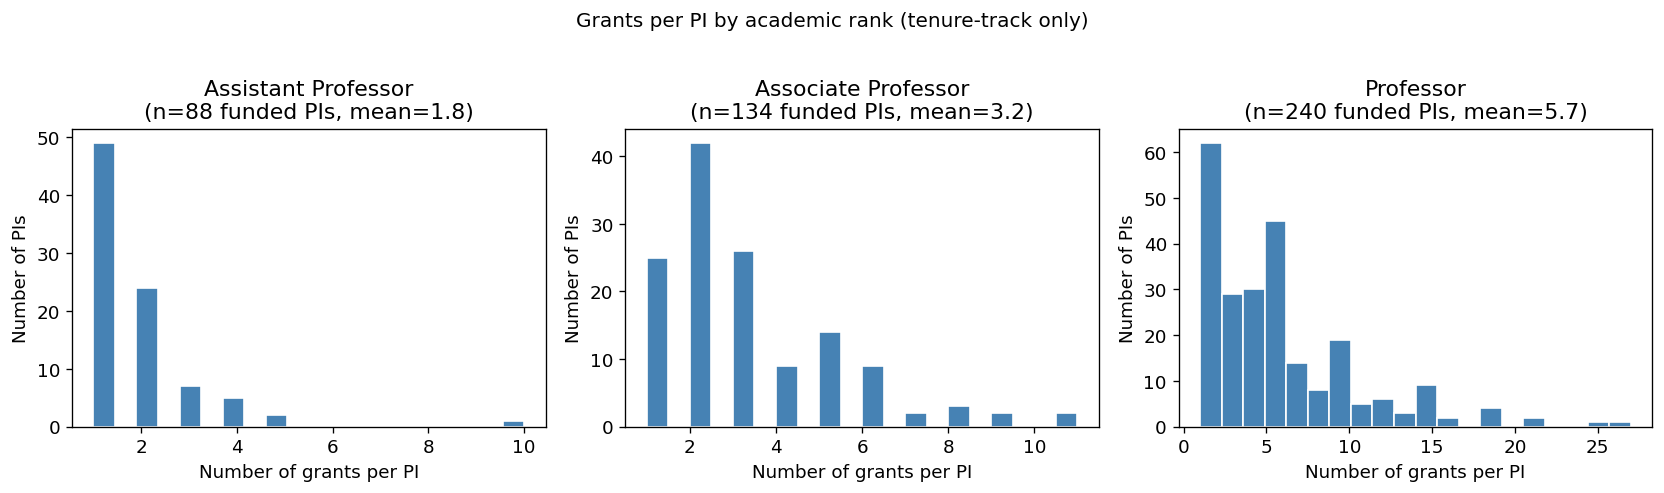

In [65]:
# Among funded tenure-track faculty: distribution of number of grants per person
# Split by academic rank for more meaningful comparison

# attach rank to grants via faculty file
rank_map = faculty_research[faculty_research['Academic Track Type'] == 'Tenure Track'][
    ['Employee ID', 'Academic Rank']].rename(columns={'Employee ID': 'ClientFacultyId'})

# drop Academic Rank from copi_deduped before merge to avoid _x _y conflict
copi_for_rank = copi_deduped.drop(columns=['Academic Rank'], errors='ignore')

grants_per_person = (
    copi_for_rank
    .merge(rank_map, on='ClientFacultyId', how='inner')
    .groupby(['ClientFacultyId', 'Academic Rank'])['GrantId']
    .count()
    .reset_index()
    .rename(columns={'GrantId': 'num_grants'})
)

# summary stats overall
print('Grants per funded tenure-track PI (all ranks):')
print(grants_per_person['num_grants'].describe())
print()
print('Distribution:')
for threshold in [1, 2, 5, 10, 20]:
    n = (grants_per_person['num_grants'] >= threshold).sum()
    print(f'  >= {threshold:2d} grants : {n} people')
print()

# summary per rank
for rank in ['Assistant Professor', 'Associate Professor', 'Professor']:
    subset = grants_per_person[grants_per_person['Academic Rank'].str.startswith(rank.split(' -')[0])]
    print(f'{rank} ({len(subset)} funded PIs):')
    print(f'  Mean: {subset["num_grants"].mean():.1f}  Median: {subset["num_grants"].median():.0f}  Max: {subset["num_grants"].max()}')

print()

# three subplots — one per rank
rank_groups = [
    ('Assistant Professor', ['Assistant Professor', 'Assistant Professor -UK']),
    ('Associate Professor', ['Associate Professor', 'Associate Professor -UK']),
    ('Professor',           ['Professor', 'Full Professor -UK']),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, (rank_label, rank_values) in zip(axes, rank_groups):
    subset = grants_per_person[grants_per_person['Academic Rank'].isin(rank_values)]['num_grants']
    ax.hist(subset.values, bins=20, color='steelblue', edgecolor='white')
    ax.set_xlabel('Number of grants per PI')
    ax.set_ylabel('Number of PIs')
    ax.set_title(f'{rank_label}\n(n={len(subset)} funded PIs, mean={subset.mean():.1f})')

plt.suptitle('Grants per PI by academic rank (tenure-track only)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('./figures/grants_per_pi_by_rank.png', dpi=150, bbox_inches='tight')
plt.show()

In [69]:
# Summary table
print(' SUMMARY')
print(f'  Total unique grants          : {len(copi_deduped):,}')
print(f'  Total funding (deduped)      : ${copi_deduped["TotalDollars"].sum()/1e6:,.1f}M')
print(f'  Unique PIs                   : {len(pi_funding):,}')
print(f'  Gini coefficient             : {gini:.3f}')
print(f'  PIs for top 80% of funding   : {top80_count} / {len(pi_funding)}')
print(f'  Top agency (NSF)             : {agency_summary.iloc[0]["pct_grants"]:.1f}% of grants')
print(f'  Top college (Engineering)    : {college_raw.iloc[0]["total_M"]:.1f}M total')
#print(f'  Collaborative grants         : {grants_with_copi_deduped:,} ({grants_with_copi_deduped/["GrantId"].nunique()*100:.1f}%)')
print(f'  Tenure-track with grants     : {funded_count} / {len(tenure_faculty)} ({funded_count/len(tenure_faculty)*100:.1f}%)')

 SUMMARY
  Total unique grants          : 2,002
  Total funding (deduped)      : $1,589.2M
  Unique PIs                   : 481
  Gini coefficient             : 0.643
  PIs for top 80% of funding   : 160 / 481
  Top agency (NSF)             : 64.6% of grants
  Top college (Engineering)    : 643.6M total
  Tenure-track with grants     : 463 / 958 (48.3%)


In [70]:
pi_college_funding = (
    copi_research
    .groupby(['Superior_Academic_Unit','PersonName'])['TotalDollars']
    .sum()
    .reset_index()
    .rename(columns={'TotalDollars':'pi_total'})
)

college_stats = (
    pi_college_funding
    .groupby('Superior_Academic_Unit')['pi_total']
    .agg(['sum','mean','median','count'])
    .rename(columns={'sum':'total_dollars','mean':'avg_per_pi',
                     'median':'median_per_pi','count':'num_funded_pis'})
)
college_stats['total_M'] = (college_stats['total_dollars'] / 1e6).round(1)
college_stats = college_stats.join(faculty_per_college)
college_stats['dollars_per_research_faculty'] = college_stats['total_dollars'] / college_stats['total_faculty']
college_stats['funded_pct'] = (college_stats['num_funded_pis'] / college_stats['total_faculty'] * 100).round(1)

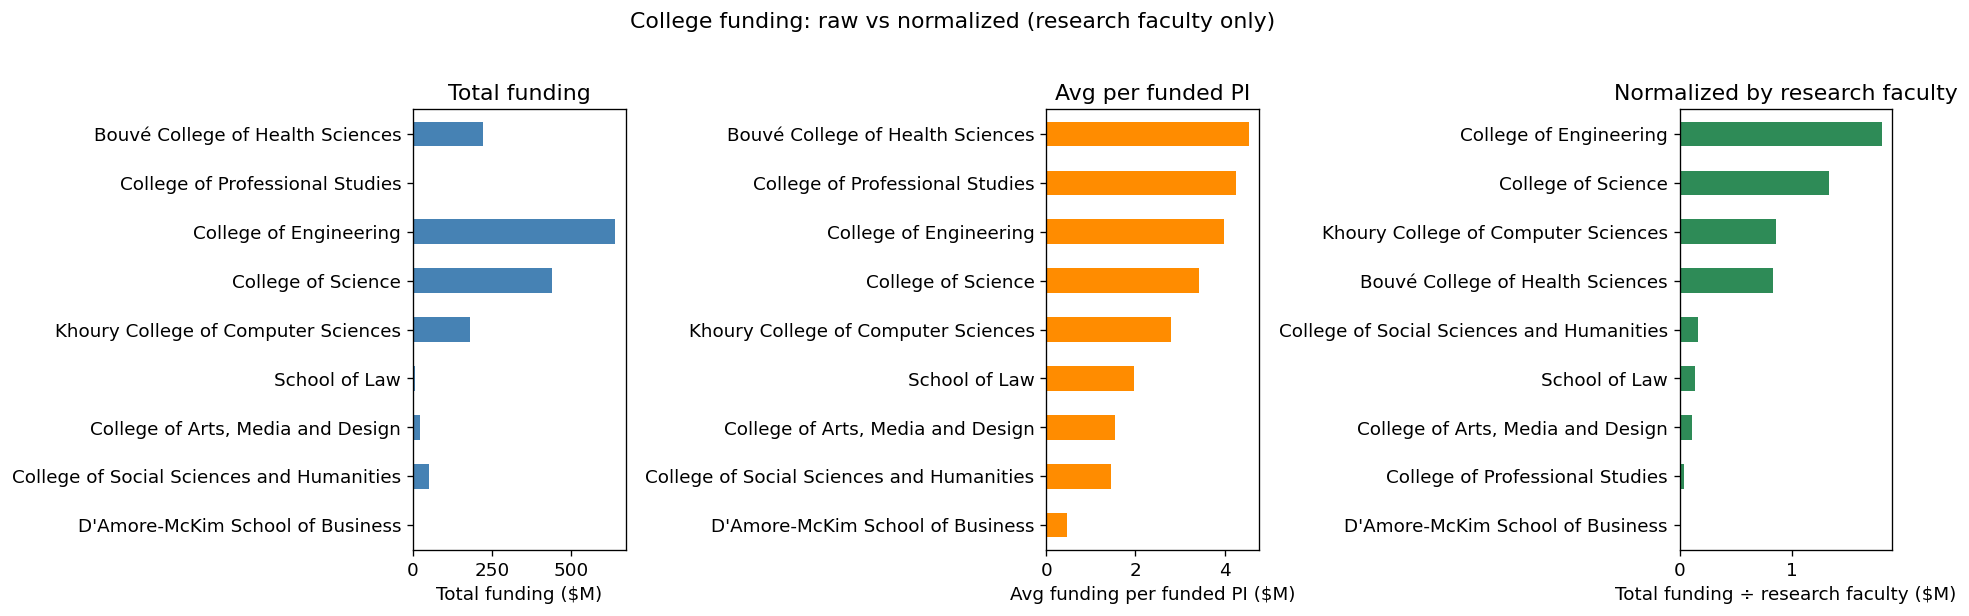

In [71]:
# Chart: avg funding per PI vs funding per research faculty — side by side per college
plot_df = college_stats.dropna().sort_values('avg_per_pi', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Total funding
plot_df['total_M'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Total funding ($M)')
axes[0].set_title('Total funding')

# Avg per funded PI
(plot_df['avg_per_pi'] / 1e6).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_xlabel('Avg funding per funded PI ($M)')
axes[1].set_title('Avg per funded PI')

# Normalized by all research faculty (including unfunded)
(plot_df['dollars_per_research_faculty'] / 1e6).sort_values().plot(kind='barh', ax=axes[2], color='seagreen')
axes[2].set_xlabel('Total funding ÷ research faculty ($M)')
axes[2].set_title('Normalized by research faculty')

for ax in axes:
    ax.set_ylabel('')

plt.suptitle('College funding: raw vs normalized (research faculty only)', y=1.02)
plt.tight_layout()
plt.savefig('./figures/college_funding_normalized.png', dpi=150, bbox_inches='tight')
plt.show()